# 1. We calculate the simple CRP case, and plot the graph of wealth with the increasing of x

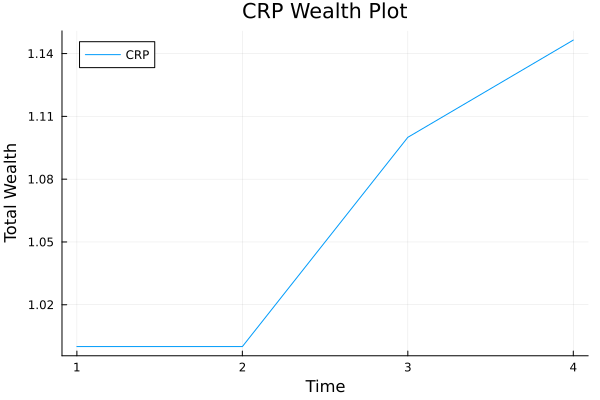

In [1]:
using Revise
using LinearAlgebra
using Plots
includet("../src.jl")
prices = [
    100.0 100.0;
    110.0  90.0;
    121.0  99.0;
    130.0 100.0
]
b = [0.5, 0.5]
wealth = crp_func(prices,b)
plot(1:length(wealth),wealth,xlabel="Time",ylabel="Total Wealth",
title="CRP Wealth Plot",label = "CRP")

In [2]:
prices_test = [
    1.0 1.0;
    2.0 1.0;
    4.0 1.0;
    8.0 1.0
]

up_wealth, b_weights, S_grid = uni_port_func(prices_test, 0.1)

println("UP wealth:")
println(up_wealth)

println("UP weights:")
println(b_weights)

println("Row sums:")
println(sum(b_weights, dims=2))

UP wealth:
[1.0, 1.5, 2.35, 3.825]
UP weights:
[0.5 0.5; 0.5 0.5; 0.5666666666666667 0.43333333333333335; 0.6276595744680851 0.3723404255319149]
Row sums:
[1.0; 1.0; 1.0; 1.0;;]


In [3]:
eta_list = [0.2, 0.1, 0.05]

benchmark_results = runtime_benchmark(prices_test, eta_list)

for row in benchmark_results
    println(row)
end

Running eta = 0.2
Running eta = 0.1
Running eta = 0.05
(eta = 0.2, num_grid_points = 6, up_final_wealth = 3.900000000000001, bcrp_final_wealth = 8.0, log_regret = 0.7184649885442349, average_log_regret = 0.23948832951474497, up_runtime = 9.0e-6, bcrp_runtime = 4.5e-6)
(eta = 0.1, num_grid_points = 11, up_final_wealth = 3.825, bcrp_final_wealth = 8.0, log_regret = 0.7378830744013365, average_log_regret = 0.2459610248004455, up_runtime = 9.7e-6, bcrp_runtime = 6.6e-6)
(eta = 0.05, num_grid_points = 21, up_final_wealth = 3.7875, bcrp_final_wealth = 8.0, log_regret = 0.7477353708443482, average_log_regret = 0.2492451236147827, up_runtime = 1.67e-5, bcrp_runtime = 6.3e-6)


In [4]:
using CSV
using DataFrames
using Plots
using LinearAlgebra
using Revise

includet("../src.jl")

price_df = CSV.read("../dataset/prices_4stocks.csv", DataFrame)

println(first(price_df, 5))
println(names(price_df))
println(size(price_df))

5×5 DataFrame
 Row │ Date        AAPL     KO       TSLA     WMT     
     │ Date        Float64  Float64  Float64  Float64 
─────┼────────────────────────────────────────────────
   1 │ 2025-01-02  242.525  59.6576   379.28  88.9641
   2 │ 2025-01-03  242.038  59.5708   410.44  89.7351
   3 │ 2025-01-06  243.669  58.664    411.05  90.3776
   4 │ 2025-01-07  240.894  58.6929   394.36  89.7648
   5 │ 2025-01-08  241.381  59.5322   394.94  90.7434
["Date", "AAPL", "KO", "TSLA", "WMT"]
(250, 5)


In [5]:
stock_cols = names(price_df)[2:end]

prices = Matrix{Float64}(select(price_df, stock_cols))

println("Stock columns: ", stock_cols)
println("Price matrix size: ", size(prices))

Stock columns: ["AAPL", "KO", "TSLA", "WMT"]
Price matrix size: (250, 4)


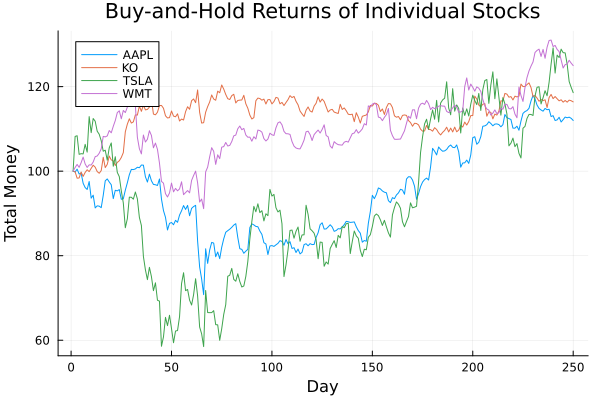

In [6]:
initial_money = 100.0

buy_hold = initial_money .* (prices ./ reshape(prices[1, :], 1, :))

p1 = plot(
    title = "Buy-and-Hold Returns of Individual Stocks",
    xlabel = "Day",
    ylabel = "Total Money",
    legend = :topleft
)

for i in 1:length(stock_cols)
    plot!(p1, buy_hold[:, i], label = stock_cols[i])
end

display(p1)

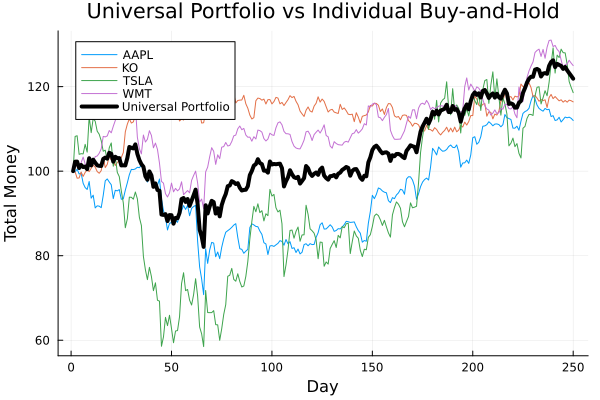

In [7]:
eta = 0.1

up_wealth, b_weights, S_grid = uni_port_func(prices, eta)

up_money = initial_money .* up_wealth

p2 = plot(
    title = "Universal Portfolio vs Individual Buy-and-Hold",
    xlabel = "Day",
    ylabel = "Total Money",
    legend = :topleft
)

for i in 1:length(stock_cols)
    plot!(p2, buy_hold[:, i], label = stock_cols[i])
end

plot!(
    p2,
    up_money,
    label = "Universal Portfolio",
    linewidth = 4,
    color = :black
)

display(p2)

In [8]:
using Plots

function regret_plot_simple(prices::Matrix{Float64}, eta::Float64)
    n, m = size(prices)

    T_list = collect(20:20:(n-1))

    log_regrets = Float64[]
    avg_log_regrets = Float64[]

    for T in T_list
        println("Running T = ", T)

        # 用前 T+1 天价格，表示 T 个投资 period
        prices_sub = prices[1:(T+1), :]

        # Universal Portfolio
        up_wealth, b_weights, S_grid = uni_port_func(prices_sub, eta)
        up_final_wealth = up_wealth[end]

        # Grid BCRP
        best_b, bcrp_final_wealth, best_wealth_set = bcrp_func_md(prices_sub, eta)

        # Regret
        R_T, avg_R_T = log_regret(bcrp_final_wealth, up_final_wealth, T)

        push!(log_regrets, R_T)
        push!(avg_log_regrets, avg_R_T)
    end

    # Plot average log regret
    p = plot(
        T_list,
        avg_log_regrets,
        marker = :circle,
        xlabel = "T",
        ylabel = "Average Log Regret R_T / T",
        title = "Average Log Regret vs Time",
        label = "R_T / T",
        linewidth = 2
    )

    hline!(p, [0.0], linestyle = :dash, label = "0")

    display(p)

    return T_list, log_regrets, avg_log_regrets
end

regret_plot_simple (generic function with 1 method)

Running T = 20
Running T = 40
Running T = 60
Running T = 80
Running T = 100
Running T = 120
Running T = 140
Running T = 160
Running T = 180
Running T = 200
Running T = 220
Running T = 240


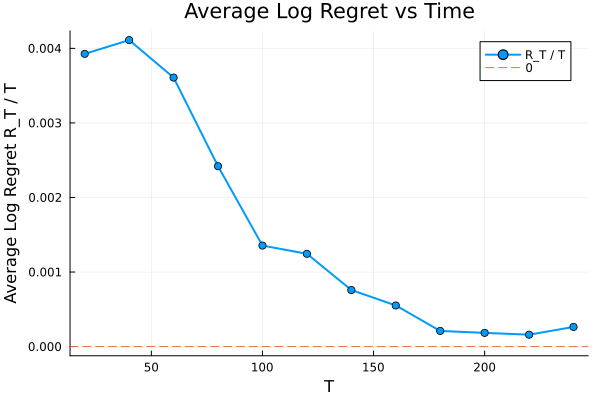

([20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240], [0.07852386818319729, 0.16445146838885694, 0.21647840079340203, 0.19351781298747506, 0.1354791665987628, 0.1493687822379155, 0.10622966916254153, 0.08828374287171202, 0.03779300491401422, 0.03681453473684679, 0.03515032285445502, 0.06330498531740536], [0.0039261934091598645, 0.004111286709721424, 0.0036079733465567004, 0.002418972662343438, 0.001354791665987628, 0.0012447398519826291, 0.0007587833511610109, 0.0005517733929482001, 0.00020996113841119008, 0.00018407267368423394, 0.00015977419479297735, 0.00026377077215585567])

In [9]:
eta = 0.1

T_list, log_regrets, avg_log_regrets = regret_plot_simple(prices, eta)

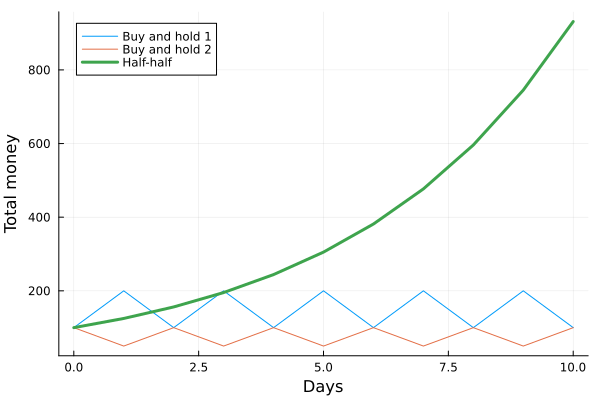

In [10]:
using Plots

# 1. 构造 toy price matrix
T = 10

prices = ones(Float64, T + 1, 2)

for t in 2:(T + 1)
    if iseven(t)
        prices[t, 1] = prices[t-1, 1] * 2.0
        prices[t, 2] = prices[t-1, 2] * 0.5
    else
        prices[t, 1] = prices[t-1, 1] * 0.5
        prices[t, 2] = prices[t-1, 2] * 2.0
    end
end

# 2. 调用你写的 CRP function
initial_money = 100.0

wealth_1 = initial_money .* crp_func(prices, [1.0, 0.0])
wealth_2 = initial_money .* crp_func(prices, [0.0, 1.0])
wealth_half = initial_money .* crp_func(prices, [0.5, 0.5])

# 3. 画图
plot(0:T, wealth_1, label = "Buy and hold 1", xlabel = "Days", ylabel = "Total money")
plot!(0:T, wealth_2, label = "Buy and hold 2")
plot!(0:T, wealth_half, label = "Half-half", linewidth = 3)